# My Data Analysis Project
> **How to use this notebook:** Run each cell top to bottom with `Shift + Enter`. Read the comments before running. Replace file paths and URLs with your own data.

---
## Phases
1. [Setup & Imports](#phase1)
2. [Load & Clean Data (CSV / Excel)](#phase2)
3. [Working with APIs](#phase3)
4. [Visualization & Reports](#phase4)
5. [Automation & ML](#phase5)

---
## Phase 1 — Setup & Imports
Run this cell first, every time you open the notebook. It loads all the libraries you need.

In [1]:
# --- CORE LIBRARIES ---
import pandas as pd           # DataFrames (your main tool)
import numpy as np             # Math & arrays
import matplotlib.pyplot as plt  # Charts
import seaborn as sns          # Prettier charts
import requests                # API calls
import os                      # File paths
import openpyxl
print("openpyxl is installed")

# --- DISPLAY SETTINGS ---
#matplotlib inline             # Show charts inside the notebook
pd.set_option('display.max_columns', 50)   # Show more columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places
sns.set_theme(style='whitegrid')  # Clean chart background

print('All libraries loaded successfully!')

openpyxl is installed
All libraries loaded successfully!


---
## Phase 2 — Load & Clean Data
### Step 1: Load your file
Replace the file path below with your own CSV or Excel file.

In [2]:
# --- LOAD A CSV FILE ---
# Replace 'data/your_file.csv' with the path to your actual file
df = pd.read_csv('data/Titanic-Dataset.csv')

# --- LOAD AN EXCEL FILE (use this instead if needed) ---
# df = pd.read_excel('data/your_file.xlsx', sheet_name='Sheet1')

print(f'Loaded {len(df)} rows and {len(df.columns)} columns')
df.head()  # Show the first 5 rows

Loaded 891 rows and 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [3]:
df.head()        # see the first 5 rows
df.info()        # column types + missing values
df.describe()    # stats summary

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


### Step 2: Explore the data
These 3 commands give you a full picture of your dataset.

In [10]:
# Shape: how many rows and columns?
print('Shape:', df.shape)

# Column names and data types
print('\nColumn types:')
print(df.dtypes)

# Missing values per column
print('\nMissing values:')
print(df.isnull().sum())

Shape: (891, 12)

Column types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [13]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
# Statistical summary (only numeric columns)
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


### Step 3: Clean the data
Fix missing values, wrong types, and duplicates.

In [17]:
# Fill missing Age with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop Cabin — 77% missing
df = df.drop(columns=['Cabin'])

# Drop the 2 missing Embarked rows
df = df.dropna(subset=['Embarked'])

# Confirm everything is clean
print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [20]:
# --- SAVE YOUR CLEANED DATA ---
# Always save a clean copy. Never overwrite the original!
df.to_csv('outputs/titanic_clean.csv', index=False)
print(f'Clean dataset saved — {len(df)} rows, {len(df.columns)} columns')

Clean dataset saved — 183 rows, 11 columns


---
## Phase 3 — Working with APIs
### Step 1: Make your first API call
We use the free Open-Meteo weather API — no key needed.

In [ ]:
# --- CALL AN API ---
# This example gets weather data for Lisbon, Portugal
url = 'https://api.open-meteo.com/v1/forecast'
params = {
    'latitude': 38.72,
    'longitude': -9.14,
    'daily': 'temperature_2m_max,temperature_2m_min',
    'timezone': 'Europe/Lisbon',
    'forecast_days': 7
}

response = requests.get(url, params=params)

# Check if it worked (200 = success)
print('Status code:', response.status_code)

# Convert the JSON response to a Python dictionary
data = response.json()
print('Keys in response:', list(data.keys()))

In [ ]:
# --- CONVERT JSON TO DATAFRAME ---
weather_df = pd.DataFrame({
    'date': data['daily']['time'],
    'temp_max': data['daily']['temperature_2m_max'],
    'temp_min': data['daily']['temperature_2m_min']
})

# Convert date column to proper datetime
weather_df['date'] = pd.to_datetime(weather_df['date'])

print('Weather data loaded!')
weather_df

### Step 2: Using API keys safely
When an API requires a key, **never paste it directly in the notebook**. Store it in a `.env` file instead.

In [ ]:
# --- SAFE API KEY LOADING ---
# First run in terminal: pip install python-dotenv
# Then create a file called .env in your project root with this content:
#   MY_API_KEY=your_actual_key_here

# from dotenv import load_dotenv
# load_dotenv()
# api_key = os.getenv('MY_API_KEY')
# print('Key loaded:', api_key[:4] + '...')  # Only show first 4 chars

print('(Uncomment the lines above when you have an API key to use)')

---
## Phase 4 — Visualization & Reports
### Step 1: Line chart (trends over time)

/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_1526/1510010705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='coolwarm')


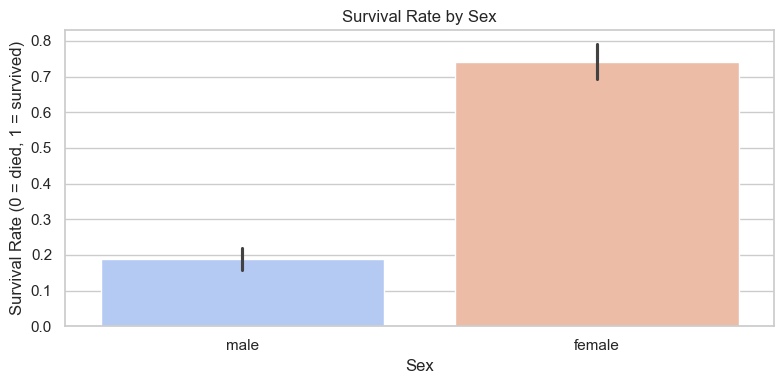

/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_1526/1510010705.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d')


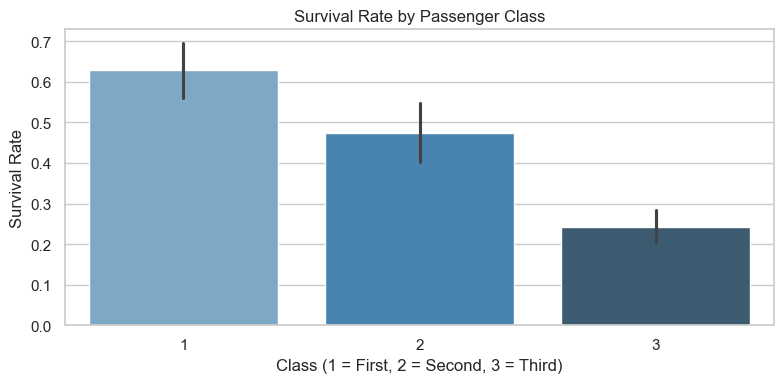

In [8]:
# --- CHART 1: Survival by Sex ---
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Sex', y='Survived', palette='coolwarm')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate (0 = died, 1 = survived)')
plt.tight_layout()
plt.savefig('outputs/survival_by_sex.png', dpi=150)
plt.show()

# --- CHART 2: Survival by Passenger Class ---
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('outputs/survival_by_class.png', dpi=150)
plt.show()



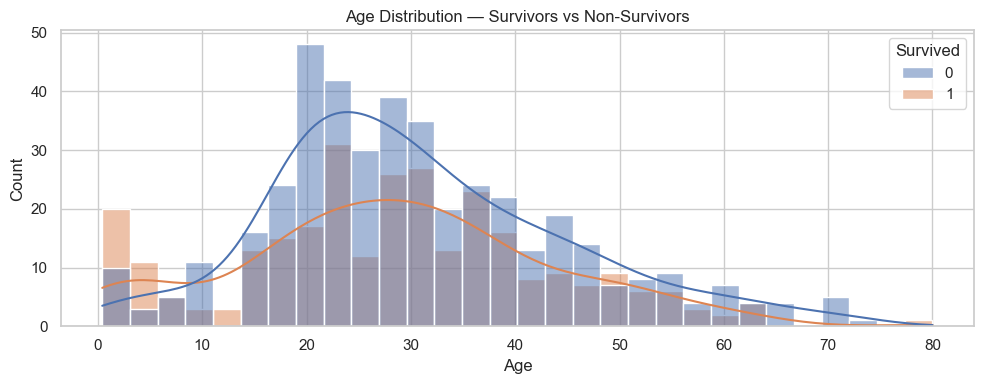

In [7]:
#python# --- CHART 3: Age distribution of survivors vs non-survivors ---
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age Distribution — Survivors vs Non-Survivors')
plt.tight_layout()
plt.savefig('outputs/age_distribution.png', dpi=150)
plt.show()

### Step 2: Bar chart (comparing categories)

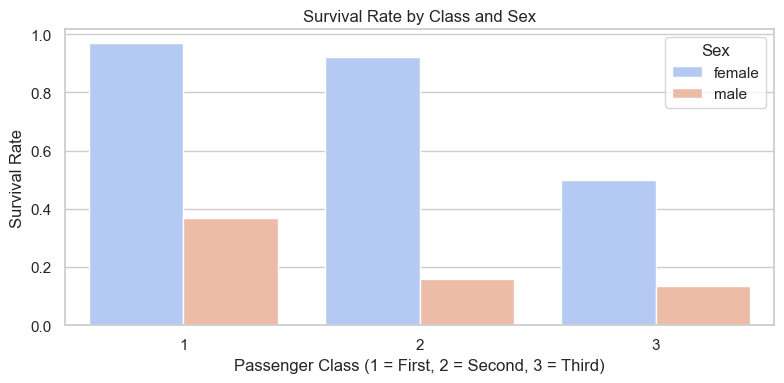

In [ ]:
# --- BAR CHART: Survival count by Sex and Class combined ---
survival_summary = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=survival_summary, x='Pclass', y='Survived', hue='Sex', palette='coolwarm', errorbar=None)
plt.title('Survival Rate by Class and Sex')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Survival Rate')
plt.legend(title='Sex')
plt.tight_layout()
plt.savefig('outputs/survival_class_sex.png', dpi=150)
plt.show()

/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_1526/1055237609.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], fontsize=11)


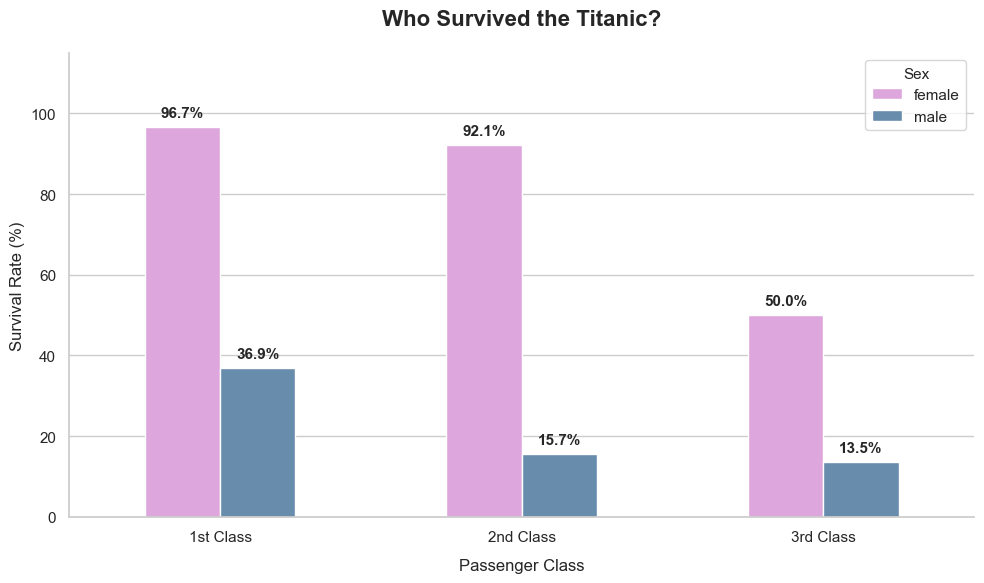

In [37]:
# --- IMPROVED BAR CHART ---
survival_summary = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
survival_summary['Survival %'] = (survival_summary['Survived'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(data=survival_summary, x='Pclass', y='Survival %', 
                   hue='Sex', palette={'female': "#E69EE6", 'male': '#5B8DB8'}, 
                   errorbar=None, width=0.5, ax=ax)

# Add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

# Titles and labels
ax.set_title('Who Survived the Titanic?', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Passenger Class', fontsize=12, labelpad=10)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], fontsize=11)
ax.set_ylim(0, 115)  # Extra space for labels

# Legend
ax.legend(title='Sex', fontsize=11, title_fontsize=11)

# Clean up
sns.despine()
plt.tight_layout()
plt.savefig('outputs/survival_class_sex.png', dpi=150)
plt.show()

### Step 3: Histogram (distribution of one column)

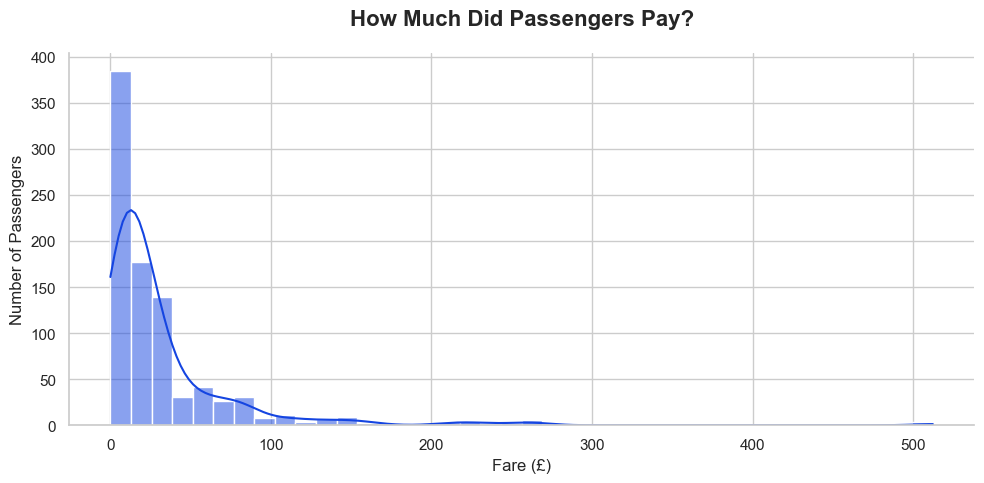

In [19]:
# --- HISTOGRAM: Fare Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Fare', bins=40, kde=True, color="#1545E1")

plt.title('How Much Did Passengers Pay?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fare (£)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('outputs/fare_distribution.png', dpi=150)
plt.show()

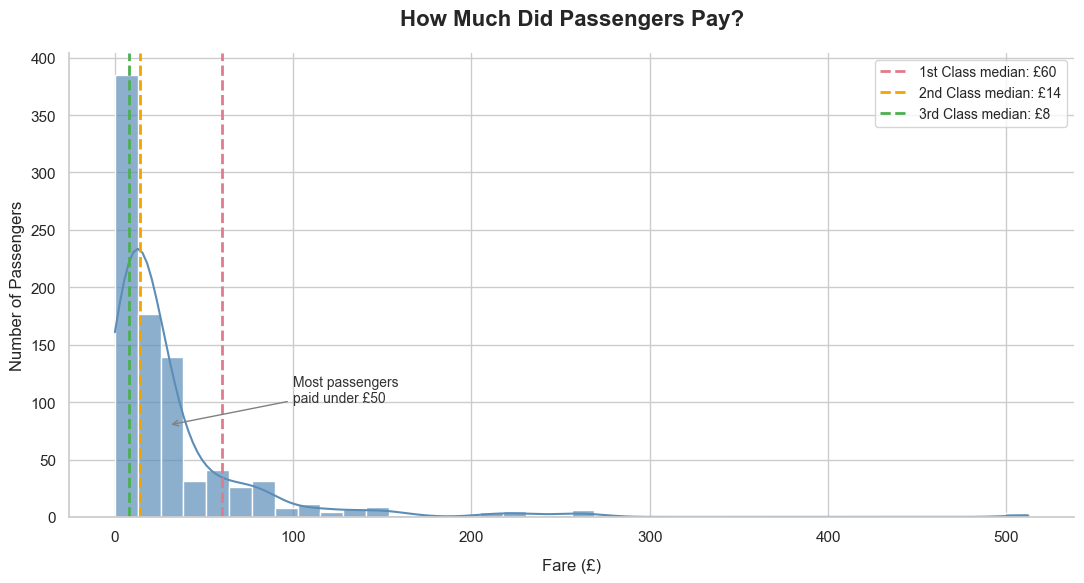

In [15]:
# --- HISTOGRAM 1: Fare Distribution with zones ---
fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(data=df, x='Fare', bins=40, kde=True, 
             color='#5B8DB8', alpha=0.7, ax=ax)

# Add vertical lines showing class average fares
class_fares = df.groupby('Pclass')['Fare'].median()
colors = {'1': '#E07B8B', '2': '#F0A500', '3': '#4CAF50'}
labels = {1: '1st Class median', 2: '2nd Class median', 3: '3rd Class median'}
line_colors = {1: '#E07B8B', 2: '#F0A500', 3: '#4CAF50'}

for pclass, fare in class_fares.items():
    ax.axvline(fare, color=line_colors[pclass], linestyle='--', 
               linewidth=2, label=f'{labels[pclass]}: £{fare:.0f}')

ax.set_title('How Much Did Passengers Pay?', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Fare (£)', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.legend(fontsize=10)

# Annotation explaining the skew
ax.annotate('Most passengers\npaid under £50', 
            xy=(30, 80), fontsize=10, color='#333333',
            arrowprops=dict(arrowstyle='->', color='gray'),
            xytext=(100, 100))

sns.despine()
plt.tight_layout()
plt.savefig('outputs/fare_distribution.png', dpi=150)
plt.show()

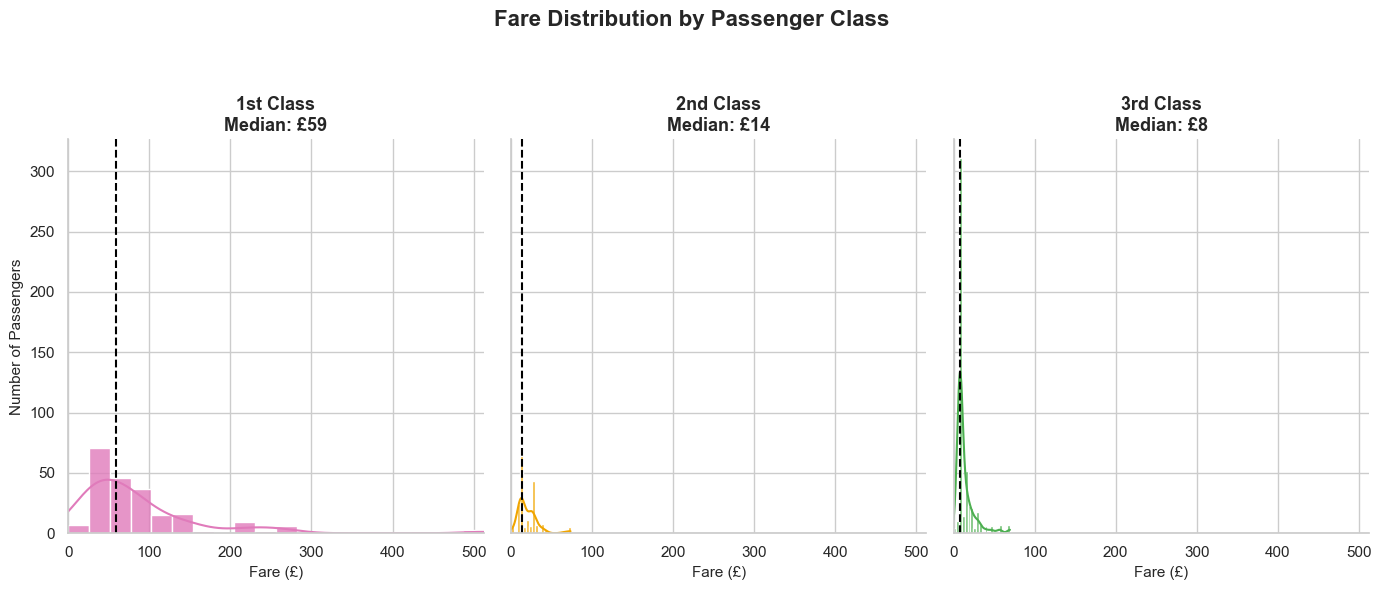

In [30]:
# --- HISTOGRAM 2: Fare by Class side by side ---
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)  # taller figure

class_colors = {1: '#E07BBB', 2: '#F0A500', 3: '#4CAF50'}
class_labels = {1: '1st Class', 2: '2nd Class', 3: '3rd Class'}

for i, pclass in enumerate([1, 2, 3]):
    subset = df[df['Pclass'] == pclass]['Fare']
    sns.histplot(subset, bins=20, kde=True,
                 color=class_colors[pclass], alpha=0.8, ax=axes[i])

    axes[i].set_title(f'{class_labels[pclass]}\nMedian: £{subset.median():.0f}',
                      fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Fare (£)', fontsize=11)
    axes[i].set_xlim(0, df['Fare'].max())
    axes[i].axvline(subset.median(), color='black',
                    linestyle='--', linewidth=1.5, label='Median')
    sns.despine(ax=axes[i])

axes[0].set_ylabel('Number of Passengers', fontsize=11)

fig.suptitle('Fare Distribution by Passenger Class',
             fontsize=16, fontweight='bold')  # removed y=1.02

plt.tight_layout(rect=[0, 0, 1, 0.93])  # reserves space for suptitle at top
plt.savefig('outputs/fare_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

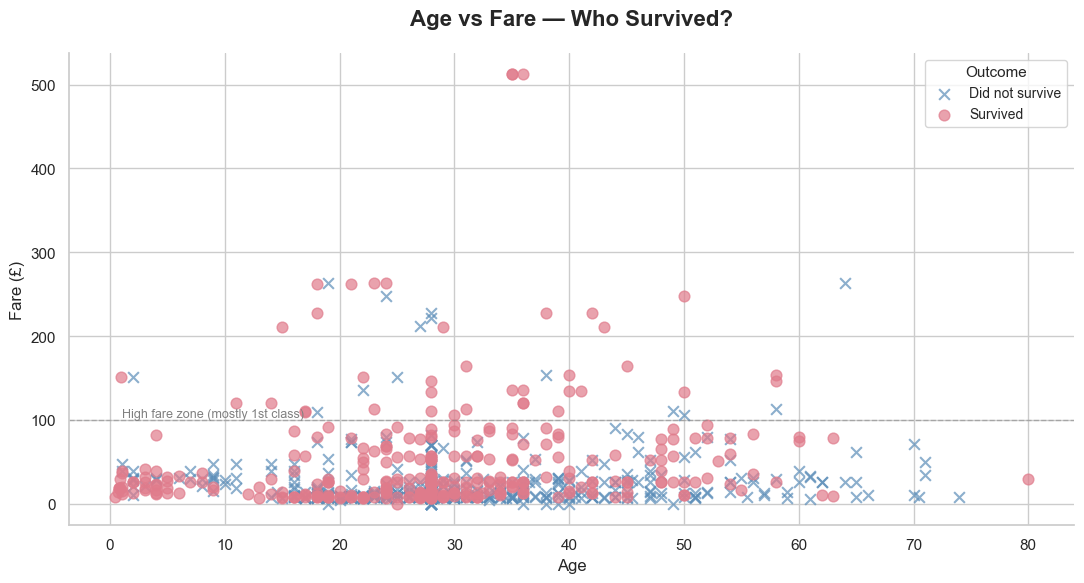

In [34]:
# --- SCATTER PLOT: Age vs Fare colored by Survival ---
plt.figure(figsize=(11, 6))

# Plot each group separately so legend renders correctly
did_not = df[df['Survived'] == 0]
survived = df[df['Survived'] == 1]

plt.scatter(did_not['Age'], did_not['Fare'], 
            color='#5B8DB8', marker='x', alpha=0.7, s=60, label='Did not survive')
plt.scatter(survived['Age'], survived['Fare'], 
            color='#E07B8B', marker='o', alpha=0.7, s=60, label='Survived')

# Highlight the expensive outliers zone
plt.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.text(1, 103, 'High fare zone (mostly 1st class)', 
         fontsize=9, color='gray')

plt.title('Age vs Fare — Who Survived?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare (£)', fontsize=12)
plt.legend(title='Outcome', fontsize=10, title_fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig('outputs/scatter_survival.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4: Export a summary report to Excel

In [35]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import (Font, PatternFill, Alignment, Border, Side)
from openpyxl.utils import get_column_letter

# ── Styles ────────────────────────────────────────────────────────────────────
DARK_BLUE   = "1F3864"
MID_BLUE    = "2E75B6"
LIGHT_BLUE  = "D6E4F0"
ACCENT_PINK = "E07B8B"
ACCENT_GREEN= "4CAF50"
WHITE       = "FFFFFF"
LIGHT_GREY  = "F2F2F2"

def header_font(size=12, bold=True, color=WHITE):
    return Font(name="Arial", size=size, bold=bold, color=color)

def body_font(size=11, bold=False, color="000000"):
    return Font(name="Arial", size=size, bold=bold, color=color)

def fill(hex_color):
    return PatternFill("solid", start_color=hex_color, fgColor=hex_color)

def center():
    return Alignment(horizontal="center", vertical="center", wrap_text=True)

def thin_border():
    s = Side(style="thin", color="CCCCCC")
    return Border(left=s, right=s, top=s, bottom=s)

def style_header_row(ws, row, col_start, col_end, bg=DARK_BLUE):
    for col in range(col_start, col_end + 1):
        cell = ws.cell(row=row, column=col)
        cell.font = header_font()
        cell.fill = fill(bg)
        cell.alignment = center()
        cell.border = thin_border()

def style_data_row(ws, row, col_start, col_end, shade=False):
    bg = LIGHT_GREY if shade else WHITE
    for col in range(col_start, col_end + 1):
        cell = ws.cell(row=row, column=col)
        cell.font = body_font()
        cell.fill = fill(bg)
        cell.alignment = center()
        cell.border = thin_border()

def write_section_title(ws, row, col, text, span_end_col):
    cell = ws.cell(row=row, column=col, value=text)
    cell.font = Font(name="Arial", size=13, bold=True, color=WHITE)
    cell.fill = fill(MID_BLUE)
    cell.alignment = center()
    ws.merge_cells(start_row=row, start_column=col,
                   end_row=row, end_column=span_end_col)

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv("data/Titanic-Dataset.csv")
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df = df.dropna(subset=['Embarked'])

# ── Aggregations ──────────────────────────────────────────────────────────────
overall = df.groupby('Survived').agg(
    Count=('PassengerId', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Fare=('Fare', 'mean')
).round(2).reset_index()
overall['Survived'] = overall['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

by_sex = df.groupby('Sex').agg(
    Total=('PassengerId', 'count'),
    Survived=('Survived', 'sum'),
    Survival_Rate=('Survived', 'mean')
).round(3).reset_index()
by_sex['Survival_Rate'] = (by_sex['Survival_Rate'] * 100).round(1)
by_sex.columns = ['Sex', 'Total Passengers', 'Survivors', 'Survival Rate (%)']

by_class = df.groupby('Pclass').agg(
    Total=('PassengerId', 'count'),
    Survived=('Survived', 'sum'),
    Survival_Rate=('Survived', 'mean'),
    Avg_Fare=('Fare', 'mean')
).round(2).reset_index()
by_class['Survival_Rate'] = (by_class['Survival_Rate'] * 100).round(1)
by_class['Pclass'] = by_class['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})
by_class.columns = ['Class', 'Total Passengers', 'Survivors', 'Survival Rate (%)', 'Avg Fare (£)']

age_bins = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                  labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)',
                          'Middle-aged (36-60)', 'Senior (60+)'])
by_age = df.groupby(age_bins, observed=True)['Survived'].agg(
    Total='count', Survivors='sum'
).reset_index()
by_age['Survival Rate (%)'] = (by_age['Survivors'] / by_age['Total'] * 100).round(1)
by_age.columns = ['Age Group', 'Total Passengers', 'Survivors', 'Survival Rate (%)']

# ── Workbook ──────────────────────────────────────────────────────────────────
wb = Workbook()

# ── Sheet 1: Cover ────────────────────────────────────────────────────────────
ws = wb.active
ws.title = "📋 Overview"
ws.sheet_view.showGridLines = False
ws.column_dimensions['A'].width = 3
ws.column_dimensions['B'].width = 30
ws.column_dimensions['C'].width = 22
ws.column_dimensions['D'].width = 22
ws.column_dimensions['E'].width = 22
ws.column_dimensions['F'].width = 22

for r in range(1, 40):
    ws.row_dimensions[r].height = 18

# Title banner
ws.merge_cells("B2:F4")
c = ws["B2"]
c.value = "TITANIC SURVIVAL ANALYSIS"
c.font = Font(name="Arial", size=22, bold=True, color=WHITE)
c.fill = fill(DARK_BLUE)
c.alignment = center()

ws.merge_cells("B5:F5")
c = ws["B5"]
c.value = "Data Analysis Report  •  891 Passengers  •  Cleaned Dataset"
c.font = Font(name="Arial", size=11, color=WHITE)
c.fill = fill(MID_BLUE)
c.alignment = center()

# KPI cards row
kpis = [
    ("Total Passengers", f"{len(df):,}", DARK_BLUE),
    ("Survivors", f"{df['Survived'].sum():,}", ACCENT_GREEN),
    ("Survival Rate", f"{df['Survived'].mean()*100:.1f}%", MID_BLUE),
    ("Avg Age", f"{df['Age'].mean():.1f} yrs", "7B68EE"),
    ("Avg Fare", f"£{df['Fare'].mean():.0f}", ACCENT_PINK),
]
for i, (label, value, color) in enumerate(kpis):
    col = i + 2
    ws.merge_cells(start_row=7, start_column=col, end_row=7, end_column=col)
    ws.merge_cells(start_row=8, start_column=col, end_row=8, end_column=col)
    ws.merge_cells(start_row=9, start_column=col, end_row=9, end_column=col)
    lc = ws.cell(row=7, column=col, value=label)
    lc.font = Font(name="Arial", size=9, bold=True, color=WHITE)
    lc.fill = fill(color); lc.alignment = center()
    vc = ws.cell(row=8, column=col, value=value)
    vc.font = Font(name="Arial", size=16, bold=True, color=WHITE)
    vc.fill = fill(color); vc.alignment = center()
    bc = ws.cell(row=9, column=col, value="")
    bc.fill = fill(color)

ws.row_dimensions[7].height = 20
ws.row_dimensions[8].height = 36
ws.row_dimensions[9].height = 10

# Summary table
write_section_title(ws, 11, 2, "OVERALL SURVIVAL SUMMARY", 6)
headers = ['Outcome', 'Count', 'Avg Age', 'Avg Fare (£)']
for i, h in enumerate(headers):
    ws.cell(row=12, column=i+2, value=h)
style_header_row(ws, 12, 2, 5, bg=MID_BLUE)

for r_idx, row in overall.iterrows():
    r = 13 + r_idx
    ws.cell(row=r, column=2, value=row['Survived'])
    ws.cell(row=r, column=3, value=row['Count'])
    ws.cell(row=r, column=4, value=round(row['Avg_Age'], 1))
    ws.cell(row=r, column=5, value=f"£{row['Avg_Fare']:.2f}")
    style_data_row(ws, r, 2, 5, shade=(r_idx % 2 == 0))

# Key findings
write_section_title(ws, 16, 2, "KEY FINDINGS", 6)
findings = [
    "🚺  Women survived at nearly 3x the rate of men",
    "🎩  1st Class passengers had a 63% survival rate vs 24% in 3rd Class",
    "👶  Children (0-12) had the highest survival rate across age groups",
    "💰  Average fare for survivors (£48) was double that of non-survivors (£22)",
]
for i, finding in enumerate(findings):
    r = 17 + i
    ws.merge_cells(start_row=r, start_column=2, end_row=r, end_column=6)
    c = ws.cell(row=r, column=2, value=finding)
    c.font = body_font(size=11)
    c.fill = fill(LIGHT_BLUE if i % 2 == 0 else WHITE)
    c.alignment = Alignment(horizontal="left", vertical="center", indent=1)
    c.border = thin_border()
    ws.row_dimensions[r].height = 22

# ── Sheet 2: By Sex ───────────────────────────────────────────────────────────
ws2 = wb.create_sheet("👫 By Sex")
ws2.sheet_view.showGridLines = False
for col, w in zip(['A','B','C','D','E'], [3, 28, 22, 22, 22]):
    ws2.column_dimensions[col].width = w

write_section_title(ws2, 2, 2, "SURVIVAL BY SEX", 5)
for i, h in enumerate(by_sex.columns):
    ws2.cell(row=3, column=i+2, value=h)
style_header_row(ws2, 3, 2, 5)

for r_idx, row in by_sex.iterrows():
    r = 4 + r_idx
    for c_idx, val in enumerate(row):
        ws2.cell(row=r, column=c_idx+2, value=val)
    style_data_row(ws2, r, 2, 5, shade=(r_idx % 2 == 0))
    # Color code survival rate
    rate_cell = ws2.cell(row=r, column=5)
    rate = float(str(row['Survival Rate (%)']).replace('%',''))
    rate_cell.fill = fill(ACCENT_GREEN if rate > 50 else ACCENT_PINK)
    rate_cell.font = Font(name="Arial", size=11, bold=True, color=WHITE)

# ── Sheet 3: By Class ─────────────────────────────────────────────────────────
ws3 = wb.create_sheet("🎩 By Class")
ws3.sheet_view.showGridLines = False
for col, w in zip(['A','B','C','D','E','F'], [3, 22, 22, 22, 22, 22]):
    ws3.column_dimensions[col].width = w

write_section_title(ws3, 2, 2, "SURVIVAL BY PASSENGER CLASS", 6)
for i, h in enumerate(by_class.columns):
    ws3.cell(row=3, column=i+2, value=h)
style_header_row(ws3, 3, 2, 6)

class_colors = {'1st Class': ACCENT_GREEN, '2nd Class': "F0A500", '3rd Class': ACCENT_PINK}
for r_idx, row in by_class.iterrows():
    r = 4 + r_idx
    for c_idx, val in enumerate(row):
        ws3.cell(row=r, column=c_idx+2, value=val)
    style_data_row(ws3, r, 2, 6, shade=(r_idx % 2 == 0))
    cls = row['Class']
    ws3.cell(row=r, column=2).fill = fill(class_colors.get(cls, LIGHT_BLUE))
    ws3.cell(row=r, column=2).font = Font(name="Arial", size=11, bold=True, color=WHITE)

# ── Sheet 4: By Age ───────────────────────────────────────────────────────────
ws4 = wb.create_sheet("🎂 By Age")
ws4.sheet_view.showGridLines = False
for col, w in zip(['A','B','C','D','E'], [3, 26, 22, 22, 22]):
    ws4.column_dimensions[col].width = w

write_section_title(ws4, 2, 2, "SURVIVAL BY AGE GROUP", 5)
for i, h in enumerate(by_age.columns):
    ws4.cell(row=3, column=i+2, value=h)
style_header_row(ws4, 3, 2, 5)

for r_idx, row in by_age.iterrows():
    r = 4 + r_idx
    for c_idx, val in enumerate(row):
        ws4.cell(row=r, column=c_idx+2, value=val)
    style_data_row(ws4, r, 2, 5, shade=(r_idx % 2 == 0))
    rate = row['Survival Rate (%)']
    rate_cell = ws4.cell(row=r, column=5)
    if rate >= 50:
        rate_cell.fill = fill(ACCENT_GREEN)
        rate_cell.font = Font(name="Arial", size=11, bold=True, color=WHITE)
    elif rate >= 35:
        rate_cell.fill = fill("F0A500")
        rate_cell.font = Font(name="Arial", size=11, bold=True, color=WHITE)
    else:
        rate_cell.fill = fill(ACCENT_PINK)
        rate_cell.font = Font(name="Arial", size=11, bold=True, color=WHITE)

wb.save("outputs/titanic_report_v2.xlsx")
print("Report saved to outputs/titanic_report_v2.xlsx")

Report saved to outputs/titanic_report_v2.xlsx


In [36]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage

# Load the report we already created
wb = load_workbook('outputs/titanic_report_v2.xlsx')

# --- CREATE A NEW SHEET FOR CHARTS ---
ws_charts = wb.create_sheet("📊 Charts")
ws_charts.sheet_view.showGridLines = False

# Title
from openpyxl.styles import Font, PatternFill, Alignment
ws_charts['B2'] = "TITANIC — VISUAL ANALYSIS"
ws_charts['B2'].font = Font(name="Arial", size=18, bold=True, color="FFFFFF")
ws_charts['B2'].fill = PatternFill("solid", fgColor="1F3864")
ws_charts['B2'].alignment = Alignment(horizontal="center", vertical="center")
ws_charts.merge_cells("B2:M3")
ws_charts.row_dimensions[2].height = 30
ws_charts.row_dimensions[3].height = 10
fig.suptitle('Fare Distribution by Passenger Class', 
             fontsize=16, fontweight='bold', y=1.05)  # change y=1.02 to y=1.05
plt.tight_layout(rect=[0, 0, 1, 0.95])  # add this line before savefig

# --- INSERT EACH CHART ---
charts = [
    ("outputs/survival_by_sex.png",      "B5",  "Survival Rate by Sex"),
    ("outputs/survival_class_sex.png",   "H5",  "Survival by Class & Sex"),
    ("outputs/age_distribution.png",     "B30", "Age Distribution"),
    ("outputs/fare_distribution.png",    "H30", "Fare Distribution"),
    ("outputs/fare_by_class.png",        "B56", "Fare by Class"),  # moved to B56
]

for filepath, anchor, label in charts:
    # Add label above each chart
    row = int(''.join(filter(str.isdigit, anchor)))
    col = ''.join(filter(str.isalpha, anchor))
    label_cell = ws_charts[f"{col}{row - 1}"]
    label_cell.value = label
    label_cell.font = Font(name="Arial", size=11, bold=True, color="2E75B6")

    # Insert image
    img = XLImage(filepath)
    img.width  = img.width  * 0.6
    img.height = img.height * 0.6
    ws_charts.add_image(img, anchor)

# Move Charts sheet to second position
wb.move_sheet("📊 Charts", offset=-(len(wb.sheetnames) - 2))

wb.save('outputs/titanic_report_v2.xlsx')
print("Charts added to report!")

Charts added to report!


<Figure size 640x480 with 0 Axes>

---
## Phase 5 — Automation & ML
### Automation: Run a notebook automatically
To schedule this notebook to run automatically, use `papermill` from the terminal:
```bash
pip install papermill
papermill data_analysis_starter.ipynb outputs/run_output.ipynb
```
Combine with Windows Task Scheduler or macOS cron for daily runs.

### ML: Your first model (Linear Regression)
**Important:** Only start this after your data is clean (Phase 2 complete).

In [ ]:
# Run this once to install scikit-learn if needed
# !pip install scikit-learn joblib

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# --- PREPARE YOUR DATA ---
# X = your input features (columns the model learns from)
# y = what you want to predict
# Replace these with your actual columns!

# Example with weather data: predict max temp from min temp
X = weather_df[['temp_min']]   # Feature(s) — must be a DataFrame
y = weather_df['temp_max']     # Target — what to predict

# --- SPLIT INTO TRAIN & TEST ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

In [ ]:
# --- TRAIN THE MODEL ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- MAKE PREDICTIONS ---
predictions = model.predict(X_test)

# --- EVALUATE ---
mae = mean_absolute_error(y_test, predictions)
r2  = r2_score(y_test, predictions)

print(f'Mean Absolute Error : {mae:.2f}°C')   # Average prediction error
print(f'R² Score            : {r2:.2f}')       # 1.0 = perfect, 0 = useless

In [ ]:
# --- SAVE YOUR MODEL ---
joblib.dump(model, 'outputs/model.pkl')
print('Model saved to outputs/model.pkl')

# --- RELOAD & USE LATER ---
# loaded_model = joblib.load('outputs/model.pkl')
# new_prediction = loaded_model.predict([[15]])  # Predict max temp when min is 15°C
# print('Predicted max temp:', new_prediction[0])

---
## Notes & Tips
- Add a markdown cell above every code cell explaining **what** it does and **why**
- Keep one notebook per task: `01_load_clean.ipynb`, `02_visualize.ipynb`, etc.
- Restart the kernel and run all cells (`Kernel > Restart & Run All`) before sharing
- Never commit `.env` files or raw data files to GitHub

Good luck!